<a href="https://colab.research.google.com/github/MiguelPartosa/Thesis-FOS-BinaryClass-WSD/blob/main/CBERT_Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers
!pip install openpyxl

In [2]:
# Importing stock ml libraries
import warnings
warnings.simplefilter('ignore')
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
import transformers
import torch
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from transformers import DistilBertTokenizer, DistilBertModel
import logging
logging.basicConfig(level=logging.ERROR)

In [21]:
fos_train_df = pd.read_excel('/content/Train_Set_WLabels.xlsx')
fos_test_df = pd.read_excel('/content/Test_Set_WLabels.xlsx')

In [22]:
fos_train_df = fos_train_df.rename(columns={"Is FOS": "is_fos"})
fos_test_df = fos_test_df.rename(columns={"Is FOS": "is_fos"})

In [23]:
from transformers import pipeline #cbert

unmasker = pipeline('fill-mask', model='GianTan/CBERTo')
unmasker("Hello I'm a [MASK] model.")

Device set to use cuda:0


[{'score': 0.017744775861501694,
  'token': 457,
  'token_str': 'sentence',
  'sequence': "hello i'm a sentence model."},
 {'score': 0.013290438801050186,
  'token': 1461,
  'token_str': 'given',
  'sequence': "hello i'm a given model."},
 {'score': 0.010848678648471832,
  'token': 4051,
  'token_str': 'story',
  'sequence': "hello i'm a story model."},
 {'score': 0.009323698468506336,
  'token': 3482,
  'token_str': 'text',
  'sequence': "hello i'm a text model."},
 {'score': 0.009105573408305645,
  'token': 1241,
  'token_str': 'list',
  'sequence': "hello i'm a list model."}]

In [24]:
tokenizer = DistilBertTokenizer.from_pretrained('GianTan/CBERTo',truncation=True, do_lower_case=False)
model = DistilBertModel.from_pretrained("GianTan/CBERTo")

In [25]:
input = tokenizer('Murag mag bata nis Gian.', return_tensors='pt')
input

{'input_ids': tensor([[   2,    1,  223,  770, 4073,    1,   20,    3]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [26]:
output = model(input_ids=input['input_ids'], attention_mask=input['attention_mask'])
output

BaseModelOutput(last_hidden_state=tensor([[[ 1.8262, -2.2653, -0.2164,  ..., -0.3576,  0.7976,  0.1592],
         [ 0.1707, -0.2825,  0.3335,  ...,  0.9750,  1.2135,  1.2772],
         [-1.1447,  0.3449, -0.0371,  ..., -0.7239,  1.3636, -1.6204],
         ...,
         [-1.5133, -1.6592,  0.0718,  ...,  0.8302,  1.3838, -0.4917],
         [-1.5697, -0.8247, -2.1634,  ..., -0.4481,  0.8399, -1.4725],
         [-1.5261, -0.4124, -0.6070,  ...,  0.5469, -1.1056, -0.0184]]],
       grad_fn=<NativeLayerNormBackward0>), hidden_states=None, attentions=None)

In [27]:
# Sections of config

# Defining some key variables that will be used later on in the training
MAX_LEN = 256
TRAIN_BATCH_SIZE = 128
VALID_BATCH_SIZE = 128
EPOCHS = 14
LEARNING_RATE = 4e-05

In [28]:
class FOS_Classification(Dataset):

    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.text = dataframe.Usage
        self.targets = self.data.is_fos
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, index):
        text = str(self.text[index])
        text = " ".join(text.split())

        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            truncation=True,
            pad_to_max_length=True,
            return_token_type_ids=True
        )
        ids = inputs['input_ids']
        mask = inputs['attention_mask']
        token_type_ids = inputs["token_type_ids"]


        return {
            'ids': torch.tensor(ids, dtype=torch.long),
            'mask': torch.tensor(mask, dtype=torch.long),
            'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
            'targets': torch.tensor(self.targets[index], dtype=torch.float)
        }

In [29]:
training_set = FOS_Classification(fos_train_df, tokenizer, MAX_LEN)
testing_set = FOS_Classification(fos_test_df, tokenizer, MAX_LEN)

In [30]:
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

test_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)

In [31]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

In [32]:
# Creating the customized model, by adding a drop out and a dense layer on top of distil bert to get the final output for the model.

class BertClass(torch.nn.Module):
    def __init__(self):
        super(BertClass, self).__init__()
        self.l1 = DistilBertModel.from_pretrained('GianTan/CBERTo')
        self.pre_classifier = torch.nn.Linear(768, 768)
        self.dropout = torch.nn.Dropout(0.3)

        self.pre_classifier2 = torch.nn.Linear(768, 768)
        self.dropout2 = torch.nn.Dropout(0.3)

        self.classifier = torch.nn.Linear(768,1)

    def forward(self, input_ids, attention_mask, token_type_ids):
        output_1 = self.l1(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0]
        pooler = hidden_state[:, 0]
        pooler = self.pre_classifier(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout(pooler)
        pooler = self.pre_classifier2(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout2(pooler)


        output = self.classifier(pooler)
        return output.squeeze(1)


model = BertClass()
model.to(device)

BertClass(
  (l1): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30000, 768, padding_idx=0)
      (position_embeddings): Embedding(256, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(in_feat

In [33]:
def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

In [34]:
optimizer = torch.optim.Adam(params =  model.parameters(), lr=LEARNING_RATE)

In [35]:
def train(epoch):
    model.train()
    for _,data in tqdm(enumerate(training_loader, 0)):
        ids = data['ids'].to(device, dtype = torch.long)
        mask = data['mask'].to(device, dtype = torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
        targets = data['targets'].to(device, dtype = torch.float)

        outputs = model(ids, mask, token_type_ids)

        optimizer.zero_grad()
        loss = loss_fn(outputs, targets)
        if _%5000==0:
            print(f'Epoch: {epoch}, Loss:  {loss.item()}')

        loss.backward()
        optimizer.step()

In [36]:
for epoch in range(EPOCHS):
    train(epoch)

1it [00:01,  1.11s/it]

Epoch: 0, Loss:  0.6764666438102722


8it [00:19,  2.41s/it]
1it [00:02,  2.80s/it]

Epoch: 1, Loss:  0.5210903286933899


8it [00:21,  2.63s/it]
1it [00:02,  2.65s/it]

...

8it [00:20,  2.54s/it]
1it [00:02,  2.62s/it]

Epoch: 12, Loss:  0.0026077793445438147


8it [00:20,  2.53s/it]
1it [00:02,  2.62s/it]

Epoch: 13, Loss:  0.0018785011488944292


8it [00:20,  2.53s/it]


In [37]:

def test_model(item):
  input_text = item
  encoded_text = tokenizer.encode_plus(
      input_text,
      None,
      add_special_tokens=True,
      max_length=MAX_LEN,
      pad_to_max_length=True,
      return_token_type_ids=True
  )

  # Convert the input to tensors
  input_ids = torch.tensor(encoded_text['input_ids']).unsqueeze(0)
  input_mask = torch.tensor(encoded_text['attention_mask']).unsqueeze(0)
  segment_ids = torch.tensor(encoded_text['token_type_ids']).unsqueeze(0)

  # Move tensors to the device
  input_ids = input_ids.to(device)
  input_mask = input_mask.to(device)
  segment_ids = segment_ids.to(device)

  # Make predictions
  with torch.no_grad():
      outputs = model(input_ids, input_mask, segment_ids)

  # Apply sigmoid activation function
  outputs = torch.sigmoid(outputs)

  # Convert the outputs to numpy array
  outputs = outputs.cpu().detach().numpy()

  return outputs

In [38]:
#  from the validation function, let me see the actual string being passed and not just the number or tensor conversion

def validation(testing_loader):
    model.eval()
    fin_targets=[]
    fin_outputs=[]

    with torch.no_grad():
        for _, data in tqdm(enumerate(testing_loader, 0)):
            ids = data['ids'].to(device, dtype = torch.long)
            mask = data['mask'].to(device, dtype = torch.long)
            token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
            targets = data['targets'].to(device, dtype = torch.float)
            outputs = model(ids, mask, token_type_ids)
            fin_targets.extend(targets.cpu().detach().numpy().tolist())
            fin_outputs.extend(torch.sigmoid(outputs).cpu().detach().numpy().tolist())

    return fin_outputs, fin_targets


In [39]:
outputs, targets = validation(testing_loader)

final_outputs = np.array(outputs) >= 0.9

print(final_outputs)
print(targets)

2it [00:03,  1.73s/it]

[False False False False False  True False  True False False False  True
  True  True  True  True False False  True False False  True  True  True
 False  True False False  True False False False  True False False  True
  True False False False False  True False False False  True  True  True
 False  True  True  True False False False False  True  True  True False
  True False  True  True  True False  True False  True False  True  True
 False  True False False False False  True False False False False  True
  True  True  True  True  True  True False  True False False False  True
  True False False False False  True  True  True  True False False  True
 False False False  True  True False  True False  True  True False False
  True False False False False False  True False False False False False
 False  True  True  True  True  True False False  True False  True False
 False False  True  True False  True False  True False False  True False
 False  True  True  True  True False  True False Fa

In [40]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

y_pred = np.array(targets)
y_true = np.array(final_outputs)

accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy Score: {accuracy:.6f}')

precision = precision_score(y_true, y_pred)
print(f'Precision Score: {precision:.6f}')

recall = recall_score(y_true, y_pred)
print(f'Recall Score: {recall:.6f}')

score_dat = f1_score(y_true, y_pred)
print(f'F1 Score: {score_dat:.6f}')


Accuracy Score: 0.926230
Precision Score: 0.934426
Recall Score: 0.919355
F1 Score: 0.926829


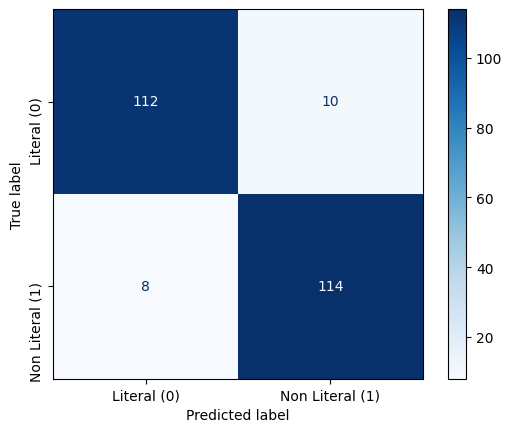

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming targets are the true labels and final_outputs are the predicted labels
y_true = np.array(targets)
y_pred = np.array(final_outputs)

class_labels = ["Literal (0)", "Non Literal (1)"]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap="Blues")  # You can change the colormap if needed

plt.yticks(rotation=90)

plt.show()

In [42]:
import os

# Directory to save checkpoints
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

def save_checkpoint(epoch, model, optimizer, loss):
    checkpoint_path = f"{checkpoint_dir}/checkpoint_epoch_{epoch}.pth"
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }, checkpoint_path)
    print(f"Checkpoint saved at {checkpoint_path}")

def train(epoch):
    model.train()
    total_loss = 0
    for _, data in tqdm(enumerate(training_loader, 0)):
        ids = data['ids'].to(device, dtype=torch.long)
        mask = data['mask'].to(device, dtype=torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype=torch.long)
        targets = data['targets'].to(device, dtype=torch.float)

        outputs = model(ids, mask, token_type_ids)

        optimizer.zero_grad()
        loss = loss_fn(outputs, targets)
        total_loss += loss.item()

        if _ % 5000 == 0:
            print(f'Epoch: {epoch}, Step: {_}, Loss: {loss.item()}')

        loss.backward()
        optimizer.step()

    # Save checkpoint after each epoch
    save_checkpoint(epoch, model, optimizer, total_loss / len(training_loader))

# Run training with checkpointing
for epoch in range(EPOCHS):
    train(epoch)

1it [00:01,  1.07s/it]

Epoch: 0, Step: 0, Loss: 0.0011372952722012997


8it [00:19,  2.41s/it]


Checkpoint saved at checkpoints/checkpoint_epoch_0.pth


1it [00:01,  1.15s/it]

...

Checkpoint saved at checkpoints/checkpoint_epoch_12.pth


1it [00:01,  1.11s/it]

Epoch: 13, Step: 0, Loss: 0.0007927664555609226


8it [00:19,  2.43s/it]


Checkpoint saved at checkpoints/checkpoint_epoch_13.pth
